Hier findet nun das räumliche Upscaling mit den

Schritt 1: Lade Daten und trainiere finales Modell...
-> Finales Random Forest Modell erfolgreich trainiert!

Schritt 2: Lade Raumausschnitt (AOI) aus DOM1_Wue.tif...
-> AOI Extent ausgelesen:
   X: 563000.0 bis 573000.0
   Y: 5513000.0 bis 5519000.0
   CRS: EPSG:25832
Schritt 3: Extrahiere statische Features (TPI & NDVI) für das AOI-Grid...
Schritt 4: Belege Meteorologie, Verkehr & Satellitendaten...
Schritt 5: Berechne PM2.5 Vorhersage...
Schritt 6: Exportiere GeoTIFF & erstelle Vorschau-Karte...


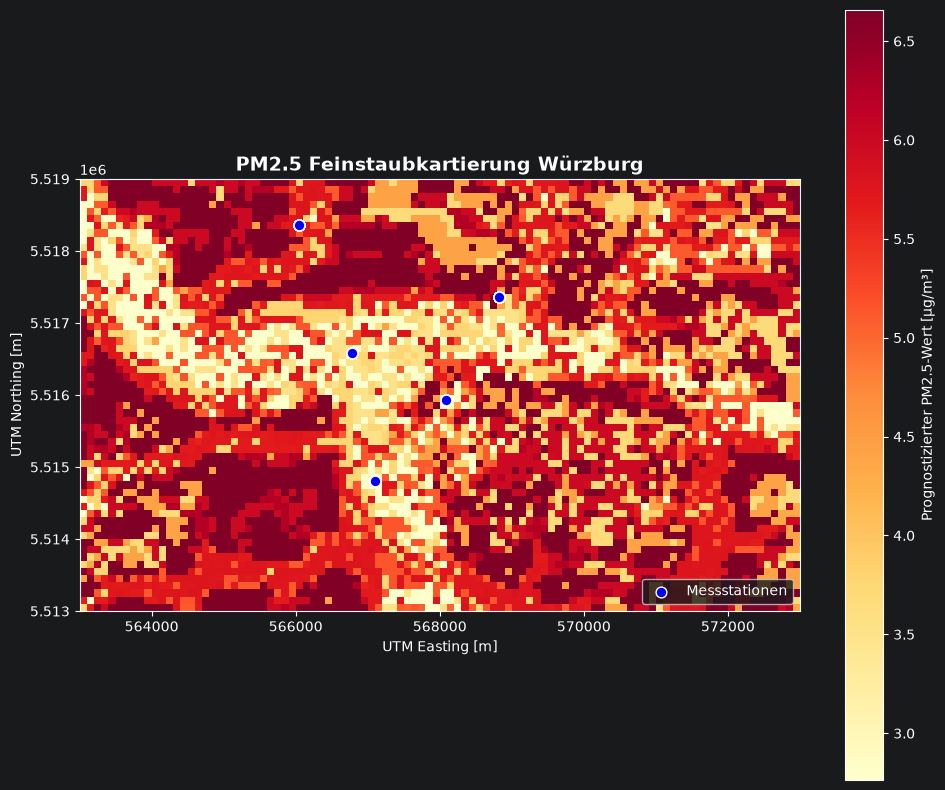

------------------------------------------------------------
ERFOLG! Das GeoTIFF für dein AOI liegt hier:
C:\Users\AD\Desktop\Uni Würzburg\EAGLE\InnoLab\new_Output/Maps\allVal_wuerzburg_pm25_upscaling_AOI_noNDVI.tif
------------------------------------------------------------


In [3]:
import os
import numpy as np
import pandas as pd
import rasterio
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
import warnings
warnings.filterwarnings('ignore')

# =========================================================
# 1. Pfade & Einstellungen
# =========================================================
base_dir = r"C:\Users\AD\Desktop\Uni Würzburg\EAGLE\InnoLab"

ml_file = os.path.join(base_dir, "new_Output", "allValues_Features_PM25_NDVI_TPI_S5P_ERA5_MAIAC_Verkehr_Wetter.csv")

# AOI Referenz-GeoTIFF (Daraus werden Extent und CRS ausgelesen)
aoi_ref_path = os.path.join(base_dir, "Daten (DOM)", "DOM1_Wue.tif")

# Pfade zu den statischen Rasterdateien für das Grid-Sampling
tpi_300_path  = os.path.join(base_dir, "Daten (DOM)", "wuerzburg_tpi_300m.tif")
tpi_1500_path = os.path.join(base_dir, "Daten (DOM)", "wuerzburg_tpi_1500m.tif")
ndvi_path     = os.path.join(base_dir, "Vorbereitete Daten für RF", "AOI_NDVI_S2_11082024.tif")

# Ausgabepfade
output_tiff = os.path.join(base_dir, "new_Output/Maps", "allVal_wuerzburg_pm25_upscaling_AOI_noNDVI.tif")
output_png  = os.path.join(base_dir, "new_Output/Maps", "allVal_wuerzburg_pm25_karte_AOI.png")

# =========================================================
# 2. Modell auf dem gesamten Datensatz trainieren
# =========================================================
print("Schritt 1: Lade Daten und trainiere finales Modell...")
df = pd.read_csv(ml_file, sep=";", decimal=",")

df['station_id'] = df['station_id'].astype(str).str.strip()

# Ungültige / fehlerhafte Sensoren ausschließen
bad_sensors = ['5456', '15449', '46505']
df = df[~df['station_id'].isin(bad_sensors)].copy()
df = df.dropna(subset=['PM25_Target'])

# Qualitätsfilter: Sensoren mit ausreichend Daten
sensor_counts = df['station_id'].value_counts()
valid_sensors = sensor_counts[sensor_counts >= 20].index
df = df[df['station_id'].isin(valid_sensors)].copy()

features = [
    'prox_kumulativ_car', 'prox_kumulativ_truck', 'IDW_car', 'IDW_truck',
    'icon_temp_2m', 'icon_wind_speed', 'icon_wind_direction', 'icon_precip_12h',
    'MAIAC_AOD', 'S5P_NO2', 'S5P_UVAI', 'ERA5_BLH', 'ndvi',
    'tpi_300m', 'tpi_1500m'
]

imputer = SimpleImputer(strategy='median')
df[features] = imputer.fit_transform(df[features])

# Trainieren des finalen Modells (Kopfklinik = Anker ID 1)
ANCHOR_ID = "1"
sample_weights = np.where(df['station_id'] == ANCHOR_ID, 1.0, 1.0)

final_rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=6,
    min_samples_leaf=4,
    random_state=42,
    n_jobs=-1
)
final_rf.fit(df[features], df['PM25_Target'], sample_weight=sample_weights)

print("-> Finales Random Forest Modell erfolgreich trainiert!")

# =========================================================
# 3. AOI Extent & CRS aus DOM1_Wue.tif auslesen
# =========================================================
print("\nSchritt 2: Lade Raumausschnitt (AOI) aus DOM1_Wue.tif...")

if not os.path.exists(aoi_ref_path):
    raise FileNotFoundError(f"Die Referenzdatei wurde nicht gefunden: {aoi_ref_path}")

with rasterio.open(aoi_ref_path) as ref_src:
    bounds = ref_src.bounds
    crs = ref_src.crs
    x_min, x_max = bounds.left, bounds.right
    y_min, y_max = bounds.bottom, bounds.top
    print(f"-> AOI Extent ausgelesen:")
    print(f"   X: {x_min:.1f} bis {x_max:.1f}")
    print(f"   Y: {y_min:.1f} bis {y_max:.1f}")
    print(f"   CRS: {crs}")

# =========================================================
# 4. 100m Punktraster über das AOI erstellen
# =========================================================
resolution = 100  # 100m Zielauflösung für das Feinstaub-Grid

x_coords = np.arange(x_min, x_max, resolution)
y_coords = np.arange(y_max, y_min, -resolution)  # Oben nach Unten für GeoTIFF Standard

grid_x, grid_y = np.meshgrid(x_coords, y_coords)
flat_x = grid_x.flatten()
flat_y = grid_y.flatten()

grid_df = pd.DataFrame({'x_utm': flat_x, 'y_utm': flat_y})
coords_list = list(zip(flat_x, flat_y))

# =========================================================
# 5. Statische Features anstechen
# =========================================================
print("Schritt 3: Extrahiere statische Features (TPI & NDVI) für das AOI-Grid...")

def sample_raster_for_grid(raster_path):
    if not os.path.exists(raster_path):
        print(f"WARNUNG: {raster_path} nicht gefunden! Belege mit Median.")
        return np.zeros(len(coords_list))

    with rasterio.open(raster_path) as src:
        nodata_val = src.nodata
        vals = [val[0] for val in src.sample(coords_list)]
        vals = np.array(vals, dtype=float)
        invalid = (vals == nodata_val) | (vals > 1e6) | (vals < -1e6) | np.isnan(vals)
        vals[invalid] = np.nanmedian(vals[~invalid]) if np.any(~invalid) else 0.0
        return vals

grid_df['tpi_300m']  = sample_raster_for_grid(tpi_300_path)
grid_df['tpi_1500m'] = sample_raster_for_grid(tpi_1500_path)
grid_df['ndvi']      = sample_raster_for_grid(ndvi_path)

# =========================================================
# 6. Dynamische Features belegen
# =========================================================
print("Schritt 4: Belege Meteorologie, Verkehr & Satellitendaten...")

for feat in ['icon_temp_2m', 'icon_wind_speed', 'icon_wind_direction',
             'icon_precip_12h', 'MAIAC_AOD', 'S5P_NO2', 'S5P_UVAI', 'ERA5_BLH',
             'prox_kumulativ_car', 'prox_kumulativ_truck', 'IDW_car', 'IDW_truck']:
    grid_df[feat] = df[feat].median()

# =========================================================
# 7. Feinstaub-Vorhersage & Matrixrekonstruktion
# =========================================================
print("Schritt 5: Berechne PM2.5 Vorhersage...")

X_grid = grid_df[features]
X_grid_imputed = imputer.transform(X_grid)

grid_df['PM25_Pred'] = final_rf.predict(X_grid_imputed)
pm25_matrix = grid_df['PM25_Pred'].values.reshape(grid_y.shape)

# =========================================================
# 8. Export als GeoTIFF mit AOI-Transformation
# =========================================================
print("Schritt 6: Exportiere GeoTIFF & erstelle Vorschau-Karte...")

transform = rasterio.transform.from_origin(x_min, y_max, resolution, resolution)

new_dataset = rasterio.open(
    output_tiff,
    'w',
    driver='GTiff',
    height=pm25_matrix.shape[0],
    width=pm25_matrix.shape[1],
    count=1,
    dtype=pm25_matrix.dtype,
    crs=crs,  # Verwendet das CRS aus DOM1_Wue.tif
    transform=transform,
)
new_dataset.write(pm25_matrix, 1)
new_dataset.close()

# =========================================================
# 9. Vorschau-Karte plotten
# =========================================================
plt.figure(figsize=(10, 8))
plt.imshow(
    pm25_matrix,
    extent=[x_min, x_max, y_min, y_max],
    cmap='YlOrRd',
    origin='upper'
)
plt.colorbar(label='Prognostizierter PM2.5-Wert [µg/m³]')
plt.title("PM2.5 Feinstaubkartierung Würzburg", fontsize=14, fontweight='bold')
plt.xlabel("UTM Easting [m]")
plt.ylabel("UTM Northing [m]")

# Messstationen einzeichnen (falls innerhalb der AOI-Grenzen)
stations_in_bounds = df[
    (df['x_utm'] >= x_min) & (df['x_utm'] <= x_max) &
    (df['y_utm'] >= y_min) & (df['y_utm'] <= y_max)
]
if len(stations_in_bounds) > 0:
    plt.scatter(
        stations_in_bounds['x_utm'],
        stations_in_bounds['y_utm'],
        color='blue', edgecolors='white', s=60, label='Messstationen', zorder=5
    )
    plt.legend(loc='lower right')

plt.tight_layout()
plt.savefig(output_png, dpi=300)
plt.show()

print("-" * 60)
print(f"ERFOLG! Das GeoTIFF für dein AOI liegt hier:\n{output_tiff}")
print("-" * 60)